In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
import os

os.path.exists("Telco-Customer-Churn.csv")

True

In [5]:
df.shape

df.info()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
df['TotalCharges']= pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

In [7]:
df['TotalCharges'].dtype

dtype('float64')

In [10]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [12]:
df.dropna(inplace=True)

In [13]:
df.drop('customerID', axis=1, inplace=True)

In [ ]:
# overall churn rate
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [ ]:
# overall churn rate percentage

df['Churn'].value_counts(normalize=True)*100

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

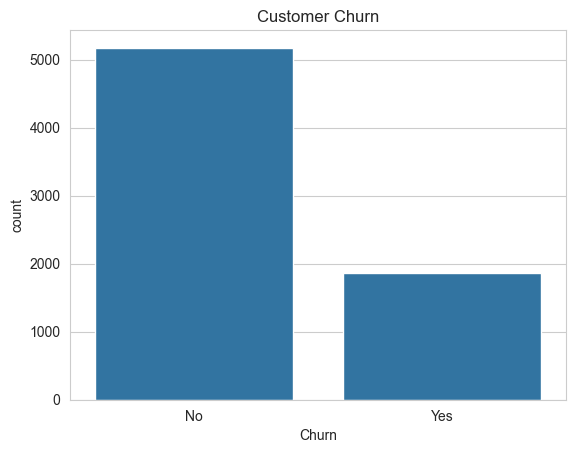

In [17]:
#visualization

sns.countplot(x='Churn', data=df)

plt.title("Customer Churn")

plt.show()

In [18]:
# does gender affect churn
pd.crosstab(
    df['gender'],
    df['Churn'],
    normalize='index'
) * 100

Churn,No,Yes
gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338


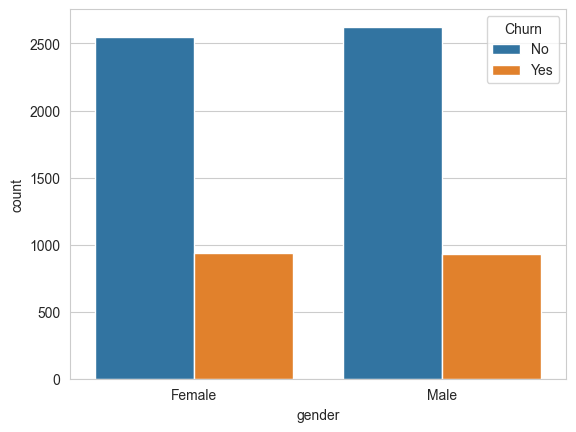

In [19]:
sns.countplot(
    x='gender',
    hue='Churn',
    data=df
)

plt.show()

In [21]:
pd.crosstab(
    df['SeniorCitizen'],
    df['Churn'],
    normalize='index'
) * 100




Churn,No,Yes
SeniorCitizen,,
0,76.393832,23.606168
1,58.318739,41.681261


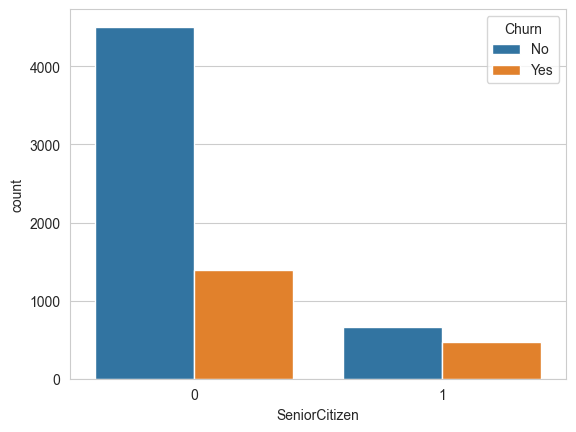

In [22]:
sns.countplot(
    x='SeniorCitizen',
    hue='Churn',
    data=df
)

plt.show()

In [26]:
# which contract type has highest churn

pd.crosstab(df['Contract'],
            df['Churn'])



Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [27]:
pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index'
) * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


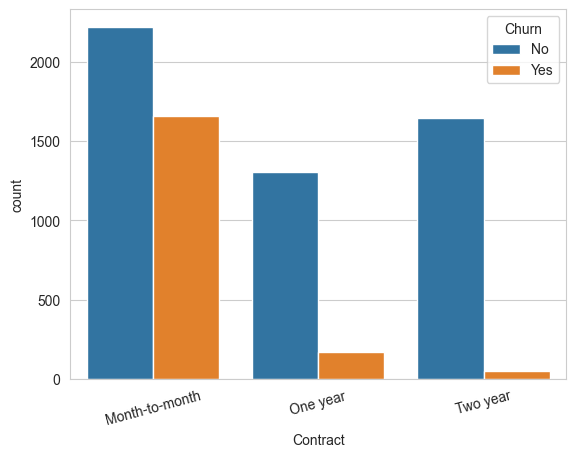

In [28]:
sns.countplot(
    x='Contract',
    hue='Churn',
    data=df
)

plt.xticks(rotation=15)

plt.show()

In [17]:
pd.crosstab(df['PaymentMethod'],
            df['Churn'])

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),1284,258
Credit card (automatic),1289,232
Electronic check,1294,1071
Mailed check,1296,308


In [32]:
pd.crosstab(
    df['PaymentMethod'],
    df['Churn'],
    normalize='index'
) * 100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


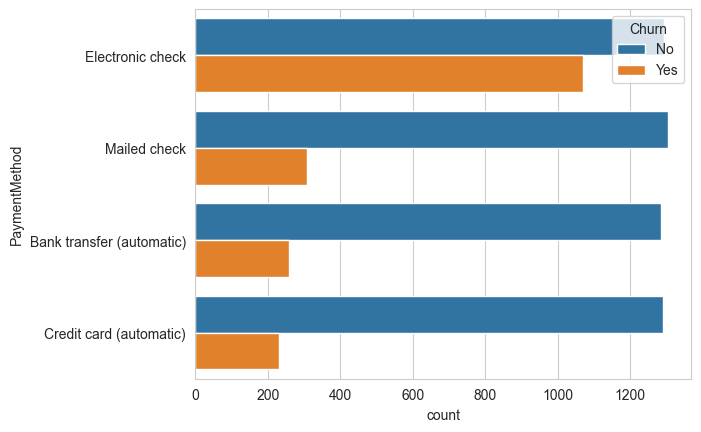

In [33]:
sns.countplot(
    y='PaymentMethod',
    hue='Churn',
    data=df
)

plt.show()

In [18]:
df.groupby('Churn')['MonthlyCharges'].mean()

Churn
No     61.307408
Yes    74.441332
Name: MonthlyCharges, dtype: float64

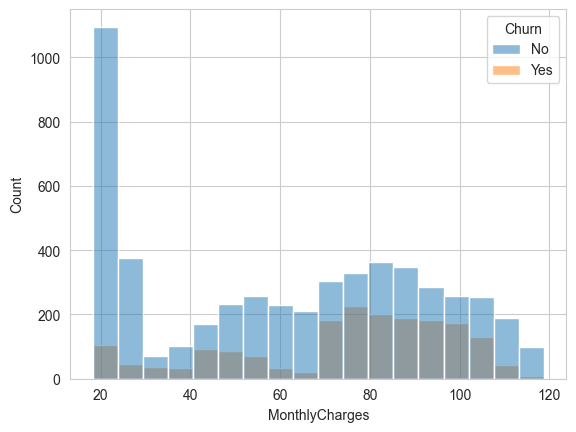

In [31]:
#

sns.histplot(
    data=df,
    x='MonthlyCharges',
    hue='Churn'
)
plt.show()

In [13]:
pd.crosstab(
    df['OnlineSecurity'],
    df['Churn'],
    normalize='index'
) * 100

Churn,No,Yes
OnlineSecurity,,
No,58.233276,41.766724
No internet service,92.595020,7.404980
Yes,85.388806,14.611194


In [15]:
pd.crosstab(
    df['InternetService'],
    df['Churn'],
    normalize='index'
) * 100

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


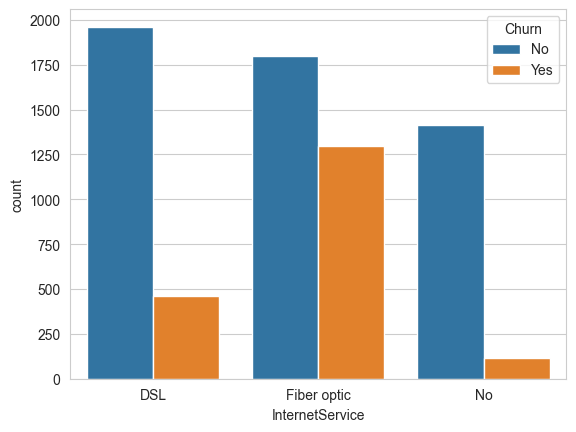

In [34]:
sns.countplot(
    x='InternetService',
    hue='Churn',
    data=df
)

plt.show()

In [19]:
df.groupby('Churn')['tenure'].mean()

Churn
No     37.650010
Yes    17.979133
Name: tenure, dtype: float64

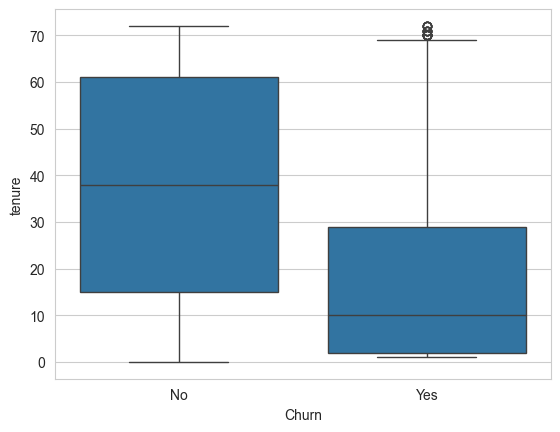

In [29]:
sns.boxplot(
    x='Churn',
    y='tenure',
    data=df
)

plt.show()

In [35]:
df.groupby('Churn')['TotalCharges'].mean()

Churn
No     2555.344141
Yes    1531.796094
Name: TotalCharges, dtype: float64

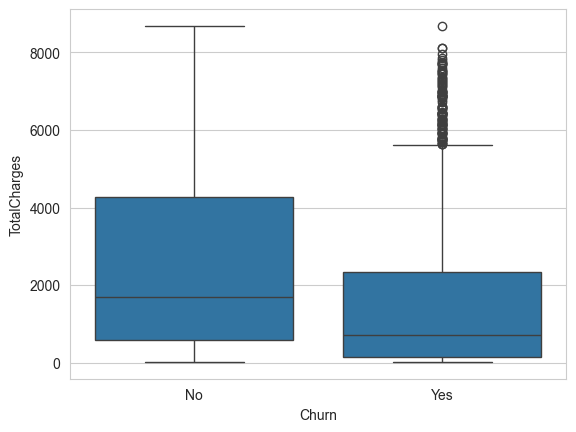

In [36]:
sns.boxplot(
    x='Churn',
    y='TotalCharges',
    data=df
)

plt.show()

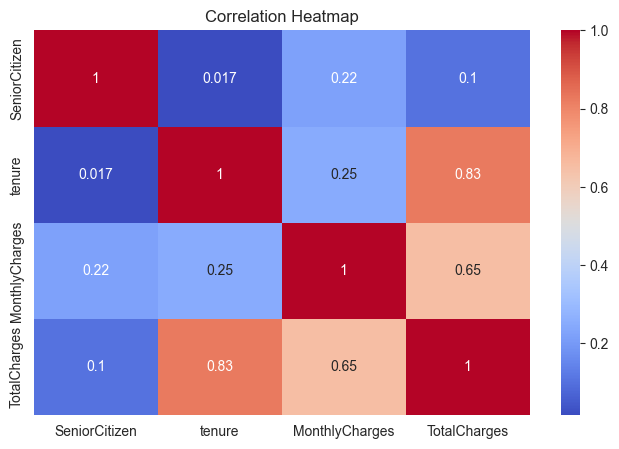

In [37]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(8,5))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [10]:
df.to_csv("Cleaned_Telco_Customer_Churn.csv", index=False)

print("CSV file created successfully!")

CSV file created successfully!


In [11]:
import os

print(os.getcwd())
print(os.listdir())

e:\DATA ANALYTICS PYTHON PROJECT
['churn_analysis.ipynb', 'Cleaned_Telco_Customer_Churn.csv', 'Telco-Customer-Churn.csv']
